In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import random as rd
import pandas as pd
from scipy.optimize import curve_fit
import pylab
from scipy.stats import t
from matplotlib.ticker import PercentFormatter


In [2]:
df_BCT = pd.read_excel('resultados_FET.xlsx', sheet_name='BCT')
df_BCT = df_BCT[df_BCT['remove'] != 1]
#df_BCT = df_BCT.dropna()
df_BCT = df_BCT.drop(2)

display(df_BCT)

,B/L,mortality,72hpf,96hpf,total_eggs,date_start,date_finish,remove,observation
0,8.0,20,0,0,20,07/07,11/07,0.0,NaN
1,8.0,10,0,0,10,11/09,15/09,0.0,NaN
3,4.0,19,0,1,20,07/07,11/07,0.0,NaN
4,4.0,18,0,2,20,10/07,14/07,0.0,NaN
5,4.0,20,0,0,20,11/07,15/07,0.0,NaN
6,3.5,4,0,2,21,18/07,22/07,0.0,NaN
7,3.5,11,0,0,20,14/07,18/07,0.0,NaN
8,3.5,8,0,3,20,14/08,18/08,0.0,NaN
9,3.0,2,0,15,20,11/07,15/07,0.0,NaN
10,3.0,1,14,18,20,10/07,14/07,0.0,bad


# BITUCA COM TABACO (BCT)

In [34]:
df_BCT['e72_c'] = df_BCT['72hpf']/df_BCT['total_eggs']
df_BCT['e96_c'] = df_BCT['96hpf']/df_BCT['total_eggs']

df_plot = df_BCT.groupby('B/L')['e96_c'].agg(['mean', 'std']).reset_index()
display(df_plot)

,B/L,mean,std
0,0.0,0.904762,NaN
1,0.5,0.980000,0.044721
2,1.0,0.950313,0.044957
3,2.0,0.962500,0.047871
4,3.0,0.633333,0.340343
5,3.5,0.081746,0.075905
6,4.0,0.050000,0.050000
7,8.0,0.000000,0.000000


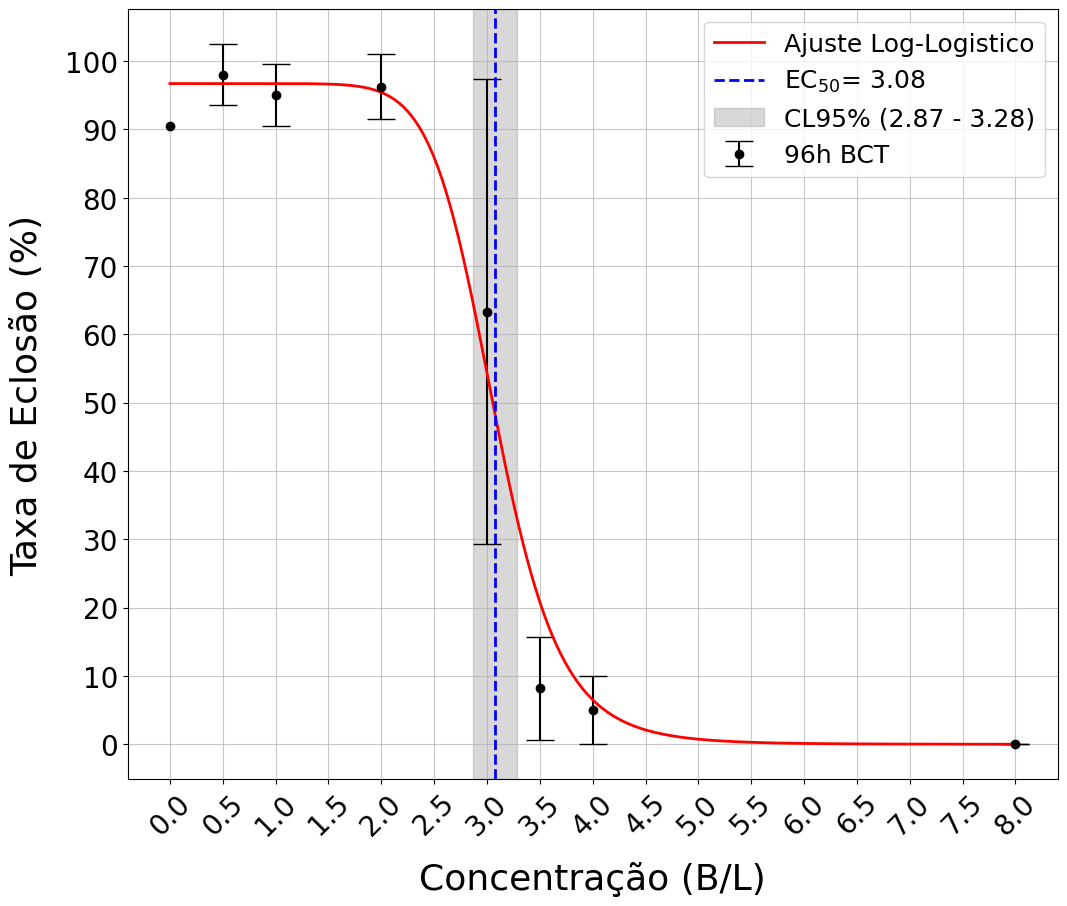

LC50: 3.0754
IC95% para LC50: [2.8682, 3.2826]


In [36]:
concentracoes = df_BCT['B/L'].values
mortalidade = df_BCT['e96_c'].values

#concentracoes = df_plot['B/L'].values
#mortalidade = df_plot['mean'].values

def loglogistic(x, a, b, c, d):
    return d + (a - d) / (1 + (x / c)**b)

popt, pcov = curve_fit(loglogistic, concentracoes, mortalidade, bounds=([0, 0, 0, 0], [1, 10, 100, 1]))
a, b, c, d = popt

perr = np.sqrt(np.diag(pcov))

n = len(concentracoes)
alpha = 0.05
tval = t.ppf(1.0 - alpha / 2., n - len(popt))
ci_lc50 = (c - tval * perr[2], c + tval * perr[2])

x_fit = np.linspace(min(concentracoes), max(concentracoes), 200)
y_fit = loglogistic(x_fit, *popt)

fig, eixo = plt.subplots(figsize=(12, 10))
plt.errorbar(df_plot['B/L'], df_plot['mean'], yerr=df_plot['std'], fmt='o', capsize=10, color='black', label='96h BCT')
plt.plot(x_fit, y_fit, label='Ajuste Log-Logistico', color='red', linestyle='-', linewidth=2)
#plt.axhline(0.5, color='blue', linestyle='--', label='50% mortality')
# Área do IC95 sombreada
plt.axvline(c, color='blue', linestyle='--', label=fr'EC$_{{50}}$= {c:.2f}', linewidth=2)
plt.axvspan(ci_lc50[0], ci_lc50[1], color='gray', alpha=0.3, label=f'CL95% ({ci_lc50[0]:.2f} - {ci_lc50[1]:.2f})')
# Linha central do LC50
plt.xlabel('Concentração (B/L)', fontsize=26, labelpad=15)
plt.ylabel('Taxa de Eclosão (%)', fontsize=26, labelpad=15)

y_values = np.arange(0, 1.1, 0.1)
x_values = np.arange(0, 8.5, 0.5)

plt.xticks(x_values, fontsize=20, rotation=45)
plt.yticks(y_values, fontsize=20)
plt.legend(fontsize=18, loc='upper right')
plt.grid(True, linestyle='-', alpha=0.7)
plt.savefig('ec50 - BCT - 96h.png')
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0, symbol=''))
plt.show()

print(f"LC50: {c:.4f}")
print(f"IC95% para LC50: [{ci_lc50[0]:.4f}, {ci_lc50[1]:.4f}]")


In [37]:
df_plot = df_BCT.groupby('B/L')['e72_c'].agg(['mean', 'std']).reset_index()
display(df_plot)

,B/L,mean,std
0,0.0,0.898810,NaN
1,0.5,0.946667,0.076739
2,1.0,0.817962,0.157670
3,2.0,0.650000,0.158114
4,3.0,0.250000,0.390512
5,3.5,0.000000,0.000000
6,4.0,0.000000,0.000000
7,8.0,0.000000,0.000000


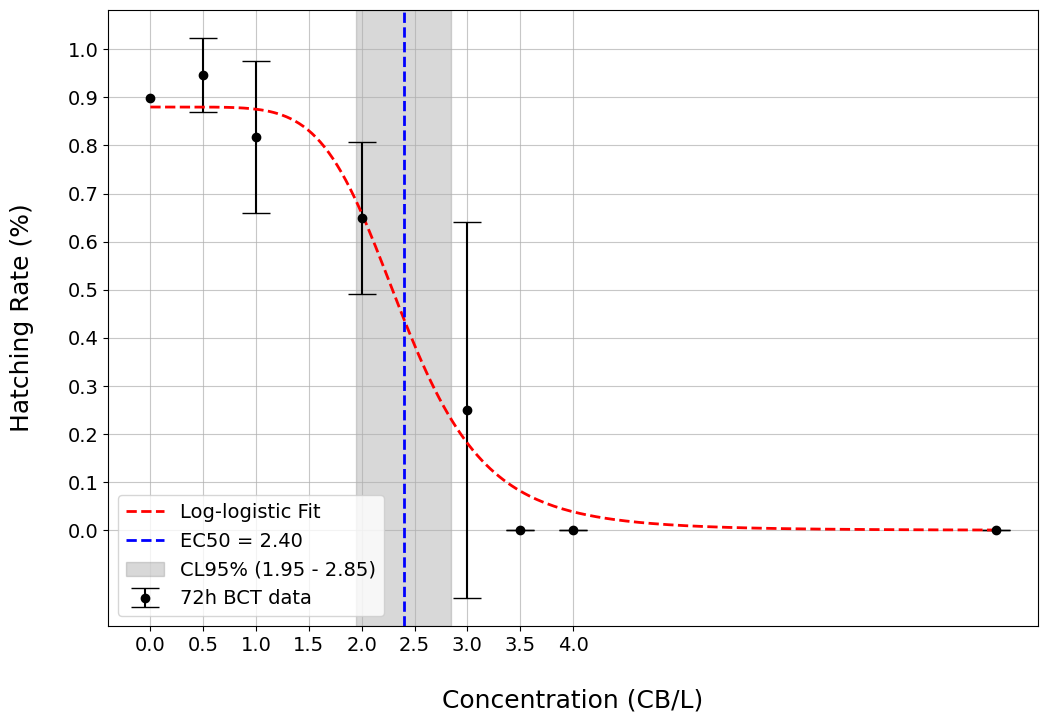

LC50: 2.3975
IC95% para LC50: [1.9480, 2.8471]


In [15]:
# Função log-logística
def loglogistic(x, a, b, c, d):
    return d + (a - d) / (1 + (x / c)**b)

# Dados
concentracoes = df_BCT['B/L'].values
mortalidade = df_BCT['e72_c'].values

# Chute inicial adequado
p0 = [1.0, 3.0, 2.0, 0.0]

# Ajuste com bounds e p0
popt, pcov = curve_fit(
    loglogistic,
    concentracoes,
    mortalidade,
    p0=p0,
    bounds=([0, 0, 0, 0], [1, 10, 100, 1])
)

# Parâmetros ajustados e erros
a, b, c, d = popt
perr = np.sqrt(np.diag(pcov))

# Intervalo de confiança de 95% para o EC50 (parâmetro c)
n = len(concentracoes)
alpha = 0.05
tval = t.ppf(1.0 - alpha / 2., n - len(popt))
ci_lc50 = (c - tval * perr[2], c + tval * perr[2])

# Curva ajustada
x_fit = np.linspace(min(concentracoes), max(concentracoes), 200)
y_fit = loglogistic(x_fit, *popt)

# Plot
fig, eixo = plt.subplots(figsize=(12, 8))
plt.errorbar(df_plot['B/L'], df_plot['mean'], yerr=df_plot['std'],
             fmt='o', capsize=10, color='black', label='72h BCT data')
plt.plot(x_fit, y_fit, label='Log-logistic Fit', color='red', linestyle='--', linewidth=2)
plt.axvline(c, color='blue', linestyle='--', label=f'EC50 = {c:.2f}', linewidth=2)
plt.axvspan(ci_lc50[0], ci_lc50[1], color='gray', alpha=0.3, label=f'CL95% ({ci_lc50[0]:.2f} - {ci_lc50[1]:.2f})')

plt.xlabel('\nConcentration (CB/L)', fontsize=18)
plt.ylabel('Hatching Rate (%)\n', fontsize=18)
plt.xticks(np.arange(0, 4.5, 0.5), fontsize=14)
plt.yticks(np.arange(0, 1.1, 0.1), fontsize=14)
plt.legend(fontsize=14, loc='lower left')
plt.grid(True, linestyle='-', alpha=0.7)
plt.savefig('ec50 - BCT - 72h.png')
plt.show()

# Resultados
print(f"LC50: {c:.4f}")
print(f"IC95% para LC50: [{ci_lc50[0]:.4f}, {ci_lc50[1]:.4f}]")


# BITUCA SEM TABACO (BST)

In [38]:
df_BST = pd.read_excel('resultados_FET.xlsx', sheet_name='BST')
#df_BST = df_BST.dropna()

df_BST = df_BST[df_BST['B/L'] != 10]
#df_BST = df_BST[df_BST['B/L'] != 8]
#df_BST = df_BST[df_BST['B/L'] != 0.5]

df_BST['e72_c'] = df_BST['72hpf']/df_BST['total_eggs']
df_BST['e96_c'] = df_BST['96hpf']/df_BST['total_eggs']

df_BST = df_BST.drop(3)

display(df_BST)

,B/L,mortality,72hpf,96hpf,total_eggs,date_start,date_finish,remove,observation,e72_c,e96_c
1,8.0,20,0,0,20,07/07,11/07,0.0,NaN,0.000000,0.000000
2,8.0,10,0,0,10,11/09,15/09,0.0,NaN,0.000000,0.000000
4,4.0,20,0,0,20,07/07,11/07,0.0,NaN,0.000000,0.000000
5,4.0,20,0,0,20,14/07,18/07,0.0,NaN,0.000000,0.000000
6,4.0,22,0,0,22,10/07,14/07,0.0,NaN,0.000000,0.000000
7,3.5,9,1,1,20,18/07,22/07,0.0,NaN,0.050000,0.050000
8,3.5,18,0,0,20,14/07,18/07,1.0,bad,0.000000,0.000000
9,3.5,10,0,0,20,08/08,12/08,0.0,NaN,0.000000,0.000000
10,3.5,11,2,4,21,11/09,15/09,0.0,NaN,0.095238,0.190476
11,3.0,2,2,2,20,18/07,22/07,0.0,NaN,0.100000,0.100000


In [39]:
df_plot96 = df_BST.groupby('B/L')['e96_c'].agg(['mean', 'std']).reset_index()

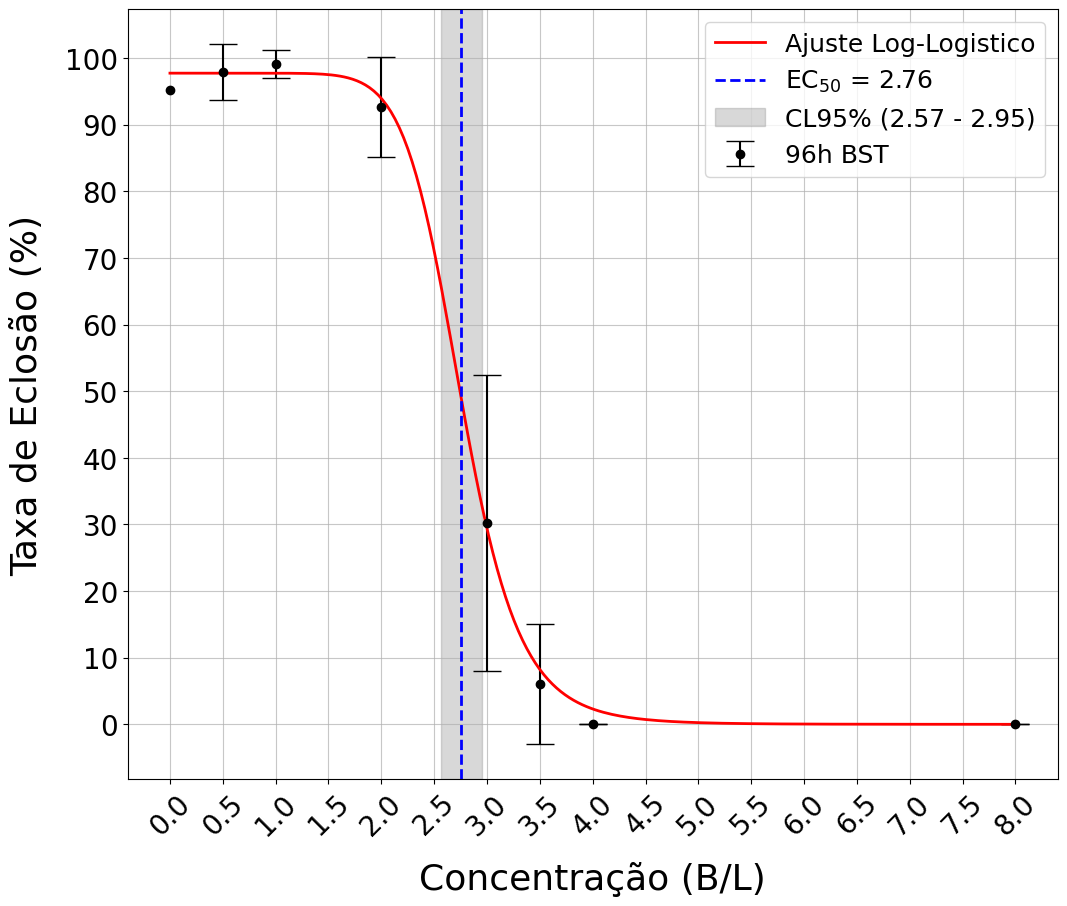

LC50: 2.7571
IC95% para LC50: [2.5654, 2.9489]


In [40]:
# Função log-logística
def loglogistic(x, a, b, c, d):
    return d + (a - d) / (1 + (x / c)**b)

# Dados

concentracoes = df_BST['B/L'].values
mortalidade = df_BST['e96_c'].values


# Chute inicial adequado
p0 = [1.0, 3.0, 2.0, 0.0]  # a=topo, b=inclinação, c=EC50, d=fundo

# Ajuste com bounds e p0
popt, pcov = curve_fit(
    loglogistic,
    concentracoes,
    mortalidade,
    p0=p0,
    bounds=([0, 0, 0, 0], [1, 10, 100, 1])
)

# Parâmetros ajustados e erros
a, b, c, d = popt
perr = np.sqrt(np.diag(pcov))

# Intervalo de confiança de 95% para o EC50 (parâmetro c)
n = len(concentracoes)
alpha = 0.05
tval = t.ppf(1.0 - alpha / 2., n - len(popt))
ci_lc50 = (c - tval * perr[2], c + tval * perr[2])

# Curva ajustada
x_fit = np.linspace(min(concentracoes), max(concentracoes), 200)
y_fit = loglogistic(x_fit, *popt)

# Plot
fig, eixo = plt.subplots(figsize=(12, 10))
plt.errorbar(df_plot96['B/L'], df_plot96['mean'], yerr=df_plot96['std'],
             fmt='o', capsize=10, color='black', label='96h BST')
plt.plot(x_fit, y_fit, label='Ajuste Log-Logistico', color='red', linestyle='-', linewidth=2)
plt.axvline(c, color='blue', linestyle='--', label=fr'EC$_{{50}}$ = {c:.2f}', linewidth=2)
plt.axvspan(ci_lc50[0], ci_lc50[1], color='gray', alpha=0.3, label=f'CL95% ({ci_lc50[0]:.2f} - {ci_lc50[1]:.2f})')

plt.xlabel('Concentração (B/L)', fontsize=26, labelpad=15)
plt.ylabel('Taxa de Eclosão (%)', fontsize=26, labelpad=15)

y_values = np.arange(0, 1.1, 0.1)
x_values = np.arange(0, 8.5, 0.5)

plt.xticks(x_values, fontsize=20, rotation=45)
plt.yticks(y_values, fontsize=20)

plt.legend(fontsize=18, loc='upper right')
plt.grid(True, linestyle='-', alpha=0.7)
plt.savefig('ec50 - BCT - 72h.png')
from matplotlib.ticker import PercentFormatter
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0, symbol=''))
plt.show()

# Resultados
print(f"LC50: {c:.4f}")
print(f"IC95% para LC50: [{ci_lc50[0]:.4f}, {ci_lc50[1]:.4f}]")


In [25]:
df_plot72 = df_BST.groupby('B/L')['e72_c'].agg(['mean', 'std']).reset_index()

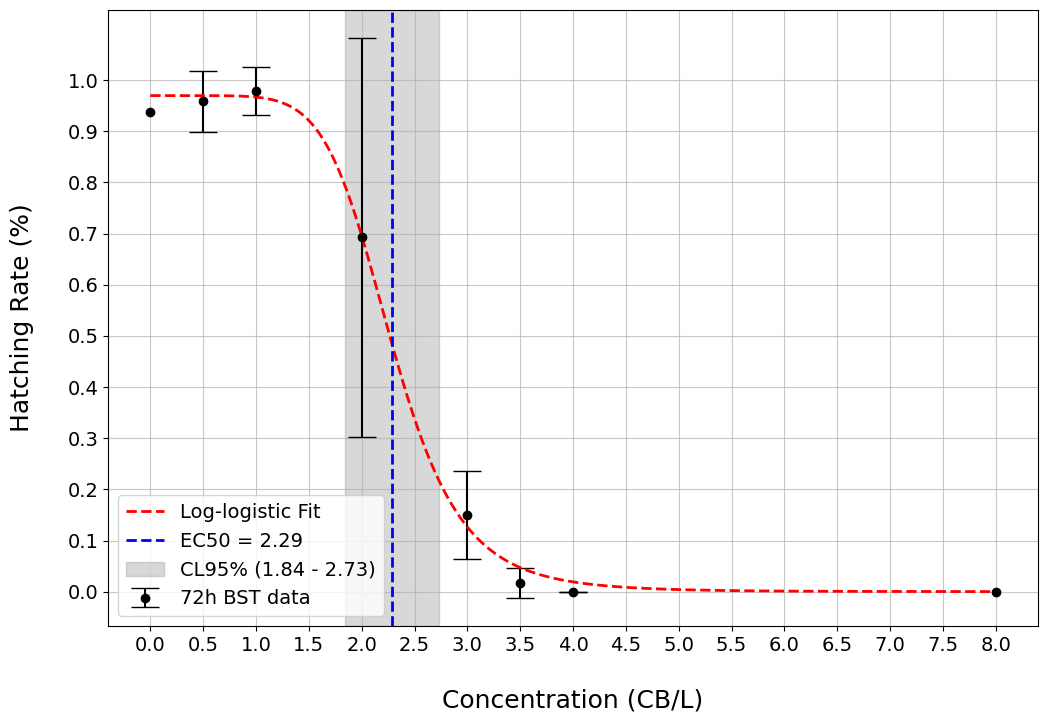

LC50: 2.2854
IC95% para LC50: [1.8413, 2.7294]


In [27]:
# Função log-logística
def loglogistic(x, a, b, c, d):
    return d + (a - d) / (1 + (x / c)**b)

# Dados

concentracoes = df_BST['B/L'].values
mortalidade = df_BST['e72_c'].values


# Chute inicial adequado
p0 = [1.0, 3.0, 2.0, 0.0]  # a=topo, b=inclinação, c=EC50, d=fundo

# Ajuste com bounds e p0
popt, pcov = curve_fit(
    loglogistic,
    concentracoes,
    mortalidade,
    p0=p0,
    bounds=([0, 0, 0, 0], [1, 10, 100, 1])
)

# Parâmetros ajustados e erros
a, b, c, d = popt
perr = np.sqrt(np.diag(pcov))

# Intervalo de confiança de 95% para o EC50 (parâmetro c)
n = len(concentracoes)
alpha = 0.05
tval = t.ppf(1.0 - alpha / 2., n - len(popt))
ci_lc50 = (c - tval * perr[2], c + tval * perr[2])

# Curva ajustada
x_fit = np.linspace(min(concentracoes), max(concentracoes), 200)
y_fit = loglogistic(x_fit, *popt)

# Plot
fig, eixo = plt.subplots(figsize=(12, 8))
plt.errorbar(df_plot72['B/L'], df_plot72['mean'], yerr=df_plot72['std'],
             fmt='o', capsize=10, color='black', label='72h BST data')
plt.plot(x_fit, y_fit, label='Log-logistic Fit', color='red', linestyle='--', linewidth=2)
plt.axvline(c, color='blue', linestyle='--', label=f'EC50 = {c:.2f}', linewidth=2)
plt.axvspan(ci_lc50[0], ci_lc50[1], color='gray', alpha=0.3, label=f'CL95% ({ci_lc50[0]:.2f} - {ci_lc50[1]:.2f})')

plt.xlabel('\nConcentration (CB/L)', fontsize=18)
plt.ylabel('Hatching Rate (%)\n', fontsize=18)
plt.xticks(np.arange(0, 8.5, 0.5), fontsize=14)
plt.yticks(np.arange(0, 1.1, 0.1), fontsize=14)
plt.legend(fontsize=14, loc='lower left')
plt.grid(True, linestyle='-', alpha=0.7)
plt.savefig('ec50 - BCT - 72h.png')
plt.show()

# Resultados
print(f"LC50: {c:.4f}")
print(f"IC95% para LC50: [{ci_lc50[0]:.4f}, {ci_lc50[1]:.4f}]")


# Bar Plot

In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
from matplotlib.colors import Normalize

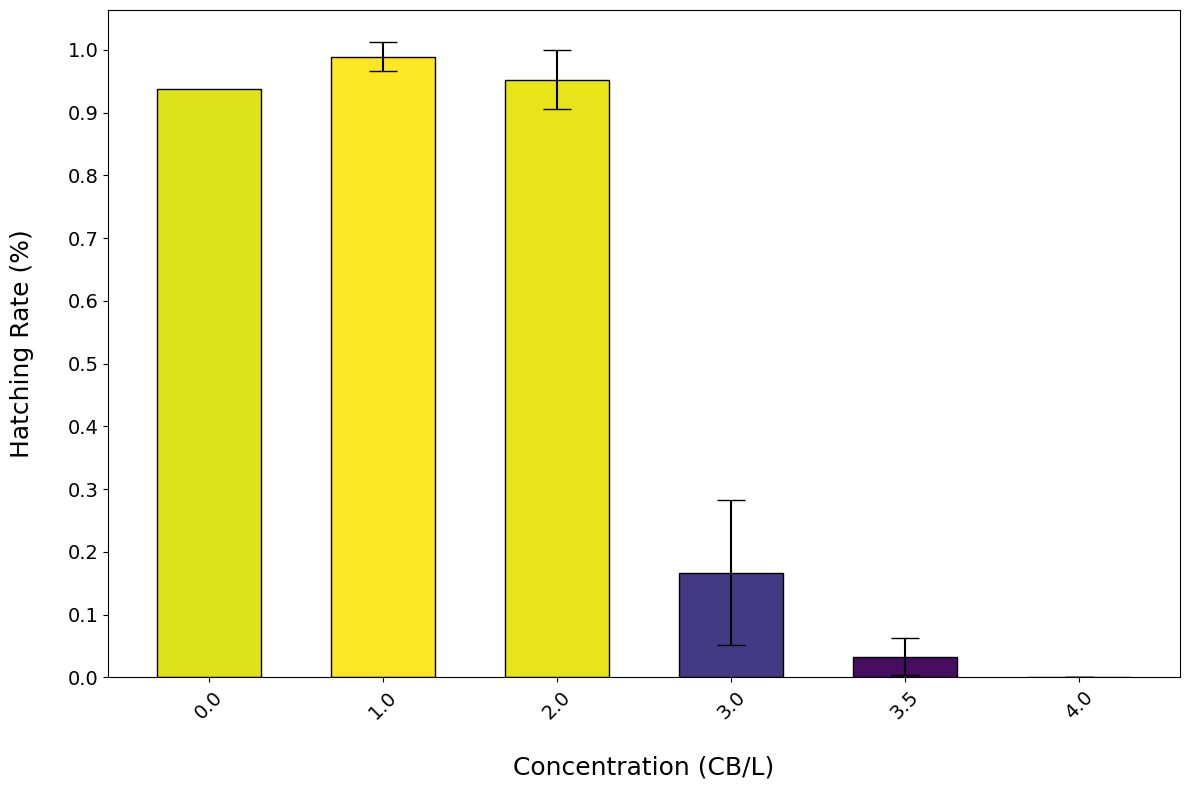

In [121]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.colors import Normalize

df_plot = df_BST.groupby('B/L')['e96_c'].agg(['mean', 'std']).reset_index()

# Normalizar cores pela coluna mean
norm = Normalize(vmin=min(df_plot['mean']), vmax=max(df_plot['mean']))
cmap = cm.viridis
colors = cmap(norm(df_plot['mean']))

y_ticks = np.arange(0, 1.1, 0.1)

# Converter B/L para string → eixo categórico
x_labels = df_plot['B/L'].astype(str)

# Criar figura
fig, eixo = plt.subplots(figsize=(12, 8))

# Plotar barras
bars = eixo.bar(
    x_labels,
    df_plot['mean'],
    yerr=df_plot['std'],
    capsize=10,
    color=colors,
    edgecolor='black',
    width=0.6
)

# Rótulos
plt.xlabel('\nConcentration (CB/L)', fontsize=18)
plt.ylabel('Hatching Rate (%)\n', fontsize=18)
plt.xticks(rotation=45, ha='center', fontsize=14)
plt.yticks(fontsize=14, ticks=y_ticks)

plt.tight_layout()
plt.show()


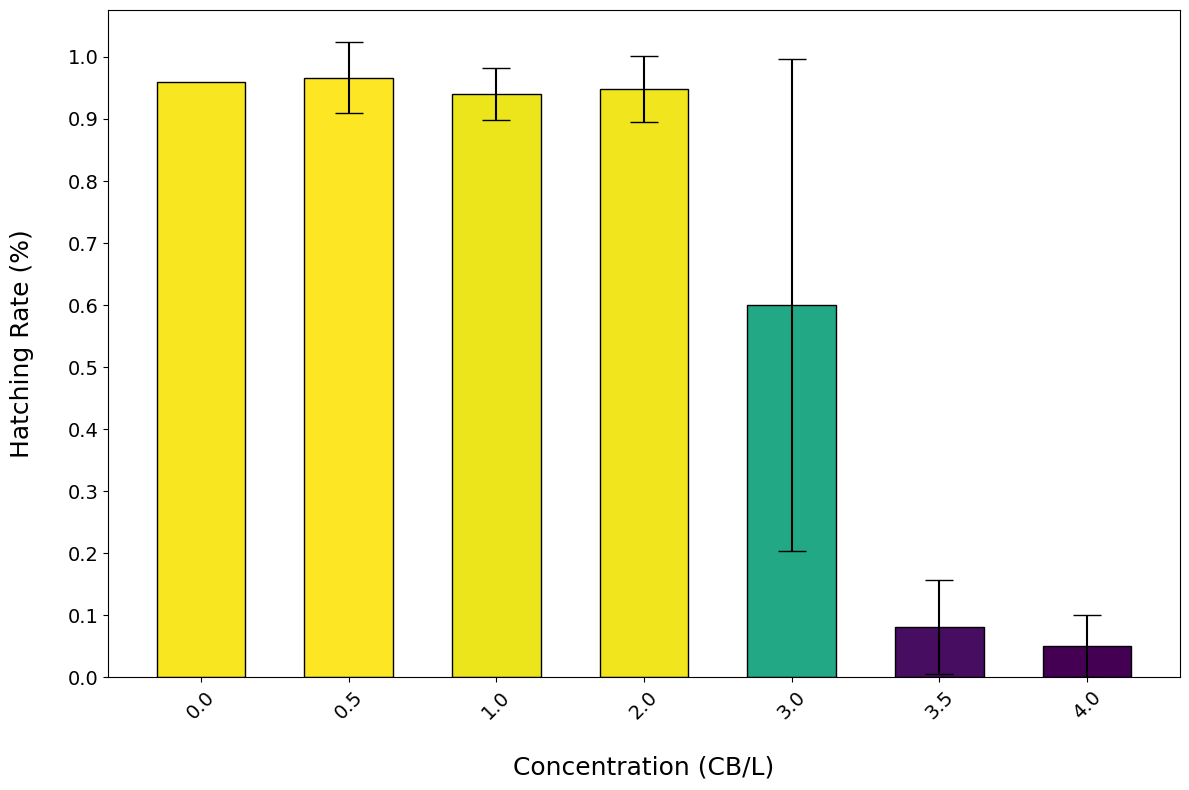

In [122]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from matplotlib.colors import Normalize

df_plot = df_BCT.groupby('B/L')['e96_c'].agg(['mean', 'std']).reset_index()

# Normalizar cores pela coluna mean
norm = Normalize(vmin=min(df_plot['mean']), vmax=max(df_plot['mean']))
cmap = cm.viridis
colors = cmap(norm(df_plot['mean']))

y_ticks = np.arange(0, 1.1, 0.1)

# Converter B/L para string → eixo categórico
x_labels = df_plot['B/L'].astype(str)

# Criar figura
fig, eixo = plt.subplots(figsize=(12, 8))

# Plotar barras
bars = eixo.bar(
    x_labels,
    df_plot['mean'],
    yerr=df_plot['std'],
    capsize=10,
    color=colors,
    edgecolor='black',
    width=0.6
)

# Rótulos
plt.xlabel('\nConcentration (CB/L)', fontsize=18)
plt.ylabel('Hatching Rate (%)\n', fontsize=18)
plt.xticks(rotation=45, ha='center', fontsize=14)
plt.yticks(fontsize=14, ticks=y_ticks)

plt.tight_layout()
plt.show()
